예제 5.7 성능 평가

In [ ]:
# 예제 5.7 MLP Fashion_MNIST(4(coat)/6(shirts) (이진 분류)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import *
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 레이블 5(sandal)/7(sneakers) 샘플 추출
index = (y_train == 5) | (y_train == 7)
x_train = x_train[index]
y_train = (y_train[index] == 5).astype(int)   # 레이블 1(5)/0(7) 재지정

index = (y_test == 5) | (y_test == 7)
x_test = x_test[index]
y_test = (y_test[index] == 5).astype(int)

# 추출한 샘플의 분포 확인
num_train_1 = np.sum(y_train == 1)   # 레이블 1인 샘플 수
num_train_0 = np.sum(y_train == 0)   # 레이블 0인 샘플 수

num_test_1 = np.sum(y_test == 1)
num_test_0 = np.sum(y_test == 0)

print(num_train_1, num_train_0)
print(num_test_1, num_test_0)

4422102/4422102 [==============================] - 1s 0us/step
6000 6000
1000 1000


In [ ]:
# 데이터 정규화
x_train, x_test = x_train / 255., x_test / 255.

In [ ]:
# 모델(MLP) 생성
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
x = Dense(16, activation='relu')(x)           # 은닉층 뉴런 16개
outputs = Dense(1, activation='sigmoid')(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

# 모델 컴파일
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics='accuracy')

# 모델 학습
model.fit(x_train, y_train, batch_size=32, epochs=2, verbose=0,
          validation_split=0.2)   # 학습 데이터/검증 데이터 분할 비율 0.2

63/63 [==============================] - 0s 2ms/step
y_test: [1 0 1 0 1]
y_pred: [1 0 1 1 0]


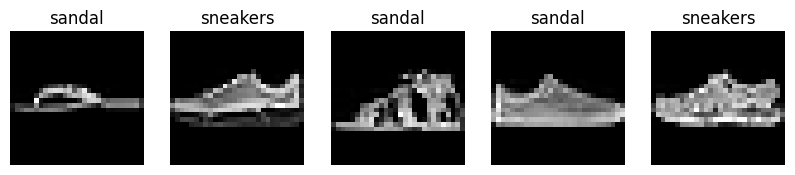

In [ ]:
# 모델 예측(임계치에 따라 0/1 판단)
class_names = ['sneakers', 'sandal']   # 클래스명

threshold = 0.5   # 임계치 0.5
y_pred = (model.predict(x_test) >= threshold).astype(int)

print(f"y_test: {y_test[:5]}")               # 테스트 데이터 레이블 확인
print(f"y_pred: {y_pred[:5].reshape(-1)}")   # 예측한 레이블 확인

# 예측 결과 시각화
plt.figure(figsize=(10, 10))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(class_names[int(y_pred[i])])   # 예측한 클래스명 표시
    plt.axis('off')

plt.show()

confusion matrix 
 [[966  34]
 [ 38 962]]
accuracy: 0.96
precision: 0.97
sensitivity(recall): 0.96
specificity: 0.97
f1 score: 0.96
AUC: 0.96


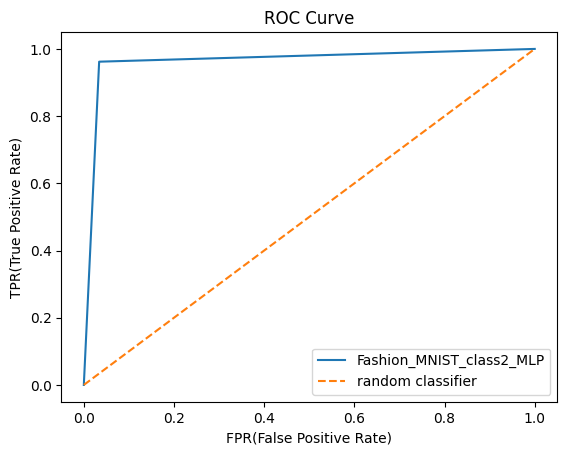

In [ ]:
#성능 평가 지표 출력
def specificity_score(y_test, y_pred):   # 특이도 함수 정의
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return tn / (tn + fp)

print(f"confusion matrix \n {confusion_matrix(y_test, y_pred)}")
print(f"accuracy: {accuracy_score(y_test, y_pred).round(2)}")
print(f"precision: {precision_score(y_test, y_pred).round(2)}")
print(f"sensitivity(recall): {recall_score(y_test, y_pred).round(2)}")
print(f"specificity: {specificity_score(y_test, y_pred).round(2)}")
print(f"f1 score: {f1_score(y_test, y_pred).round(2)}")
print(f"AUC: {roc_auc_score(y_test, y_pred).round(2)}")

# ROC 곡선 출력
fpr, tpr, thresholds = roc_curve(y_test, y_pred)      # fpr/tpr 값 계산

plt.plot(fpr, tpr, label='Fashion_MNIST_class2_MLP')        # ROC 곡선
plt.plot([0, 1], [0, 1], '--', label='random classifier')   # 대각 점선
plt.title('ROC Curve')
plt.xlabel('FPR(False Positive Rate)')
plt.ylabel('TPR(True Positive Rate)')
plt.legend(loc='lower right')

plt.show()